# Part 1 - Dry Bean Dataset

## Section A - Data Exploration & Visualization

In [ ]:
#Data spliting 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

#Load dataset 
df = pd.read_csv('Dry_Beans_Filtered_Assignment3.csv') 

#Split the data 80/10/10
train_df, temp_df = train_test_split(df, test_size=0.20, random_state=42, stratify=df['Class'])
val_df, test_df = train_test_split(temp_df, test_size=0.50, random_state=42, stratify=temp_df['Class'])

#We will perform EDA ONLY on train_df

### Visualization 1: Class Distribution

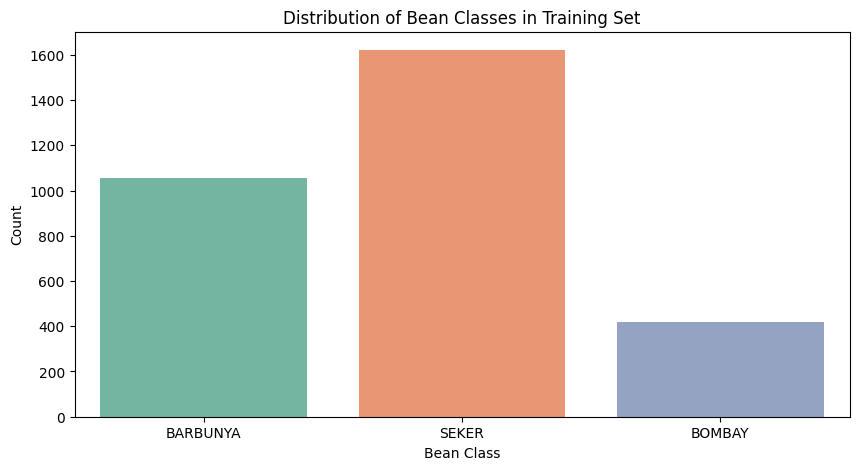

In [ ]:
plt.figure(figsize=(10, 5))
sns.countplot(data=train_df, x='Class', hue='Class', palette='Set2', legend=False)
plt.title('Distribution of Bean Classes in Training Set')
plt.xlabel('Bean Class')
plt.ylabel('Count')
plt.show()

This bar chart shows the number of beans in each class. It helps us see if our dataset is balanced. If some classes have many more observations than others, we might need to handle this imbalance later when training our classification models. This helps us understand the baseline data distribution.

### Visualization 2: Feature Distribution with Statistics

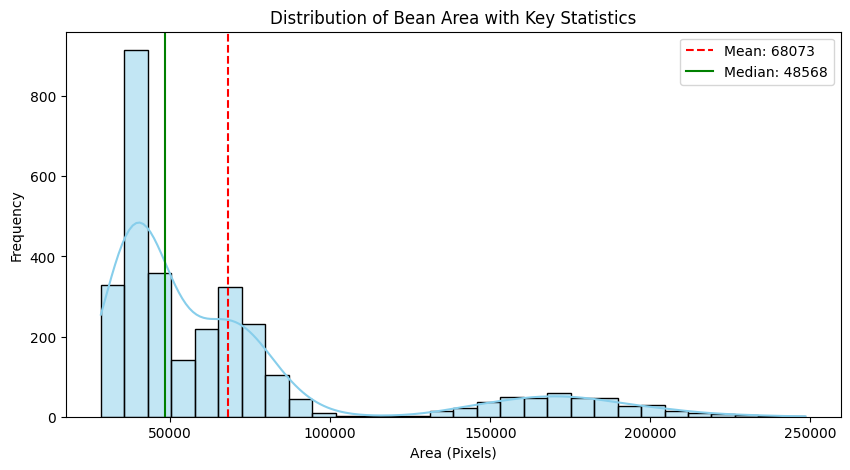

In [ ]:
plt.figure(figsize=(10, 5))
sns.histplot(data=train_df, x='Area', kde=True, bins=30, color='skyblue')

# Add mean and median lines
mean_val = train_df['Area'].mean()
median_val = train_df['Area'].median()
plt.axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.0f}')
plt.axvline(median_val, color='green', linestyle='-', label=f'Median: {median_val:.0f}')

plt.title('Distribution of Bean Area with Key Statistics')
plt.xlabel('Area (Pixels)')
plt.ylabel('Frequency')
plt.legend()
plt.show()

This plot displays the distribution of the 'Area' feature across all beans. We can see the shape of the data and its main statistics. The red dashed line shows the mean, and the green line shows the median. If the distribution is not symmetrical, it suggests we might need to apply a transformation like log or standard scaling during the pre-processing phase to help our models perform better.

### Visualization 3: Shape Feature Comparison

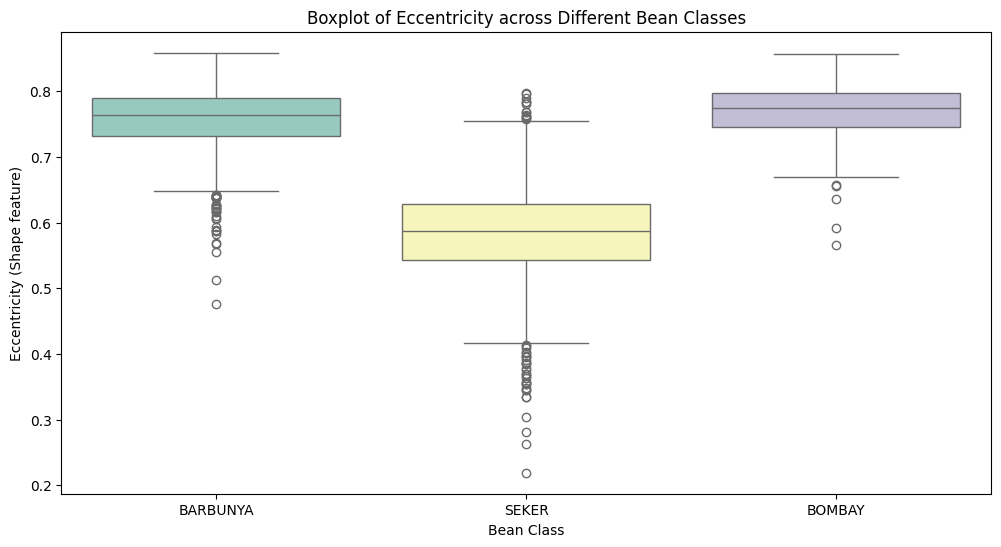

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=train_df, x='Class', y='Eccentricity', hue='Class', palette='Set3', legend=False)
plt.title('Boxplot of Eccentricity across Different Bean Classes')
plt.xlabel('Bean Class')
plt.ylabel('Eccentricity (Shape feature)')
plt.show()

This boxplot compares how elongated the bean is across different classes. It clearly shows that certain bean classes have very different shapes. For example, some classes are much rounder while others are longer. This indicates that geometric features will be highly valuable for our classification models to separate the classes. It also highlights potential outliers in the data.

### Visualization 4: Pairwise Feature Separation

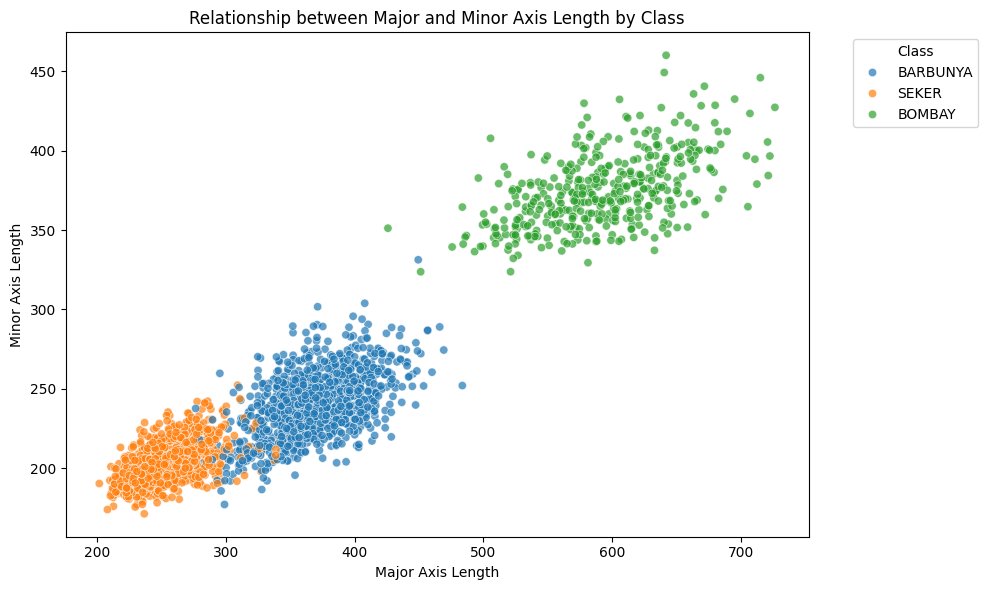

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=train_df, x='MajorAxisLength', y='MinorAxisLength', hue='Class', palette='tab10', alpha=0.7)
plt.title('Relationship between Major and Minor Axis Length by Class')
plt.xlabel('Major Axis Length')
plt.ylabel('Minor Axis Length')
plt.legend(title='Class', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

This scatter plot plots two geometric features against each other, colored by the bean class. We can see the clusters forming. This tells us that combinations of simple structural features contain enough information to distinguish between specific bean types. This observation supports our expectation that clustering algorithms and classifiers will likely perform well.

### Visualization 5: Correlation Heatmap

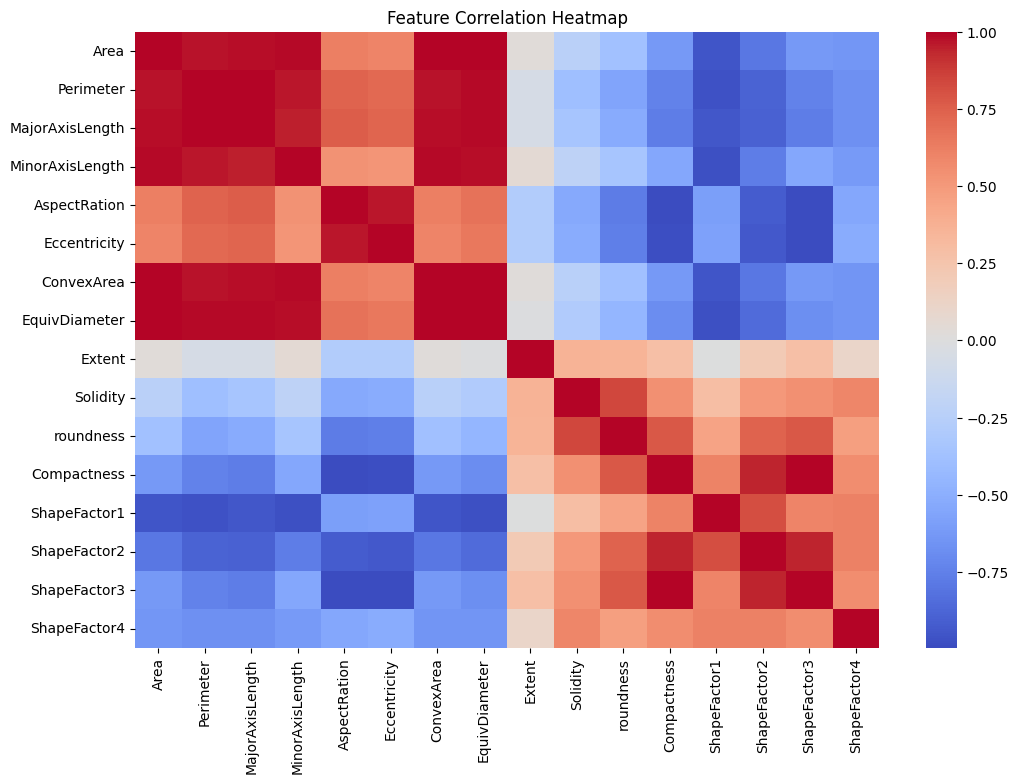

In [ ]:
plt.figure(figsize=(12, 8))
# Select only numeric columns for correlation
numeric_cols = train_df.select_dtypes(include=[np.number])
correlation_matrix = numeric_cols.corr()

sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation Heatmap')
plt.show()

This heatmap shows the correlation between all numerical features. Dark red or dark blue squares indicate a very strong correlation between two variables. We can see that many geometric features are highly correlated with each other, making redundant information. This strongly justifies the use of Dimensionality Reduction techniques like PCA later, as it can reduce this redundancy while keeping the predictive performance.

## Section B - Data Pre-processing

In [ ]:
import numpy as np

def add_engineered_features(df):
    """
    Adds 3 new geometric features to the dataframe.
    """
    df_new = df.copy()

    df_new['AxisRatio'] = df_new['MajorAxisLength'] / df_new['MinorAxisLength']
   
    df_new['ShapeFactor_Perimeter'] = (4 * np.pi * df_new['Area']) / (df_new['Perimeter'] ** 2)

    df_new['EqDiameter'] = np.sqrt((4 * df_new['Area']) / np.pi)
    
    return df_new

train_df = add_engineered_features(train_df)
val_df = add_engineered_features(val_df)
test_df = add_engineered_features(test_df)

Engineered Features Explanation:

AxisRatio: Calculates the ratio between the major and minor axes. This represents the elongation of the bean. A value closer to 1 means the bean is more circular.

ShapeFactor_Perimeter: Measures the compactness of the bean by comparing its area to its perimeter squared. A perfect circle has the highest value, making it easier for the model to distinguish between smooth/round beans and jagged/elongated ones.

EqDiameter: Converts the 2D 'Area' into a 1D length metric (the diameter of a circle with the same area). This helps linearize the area feature.

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

X_train = train_df.drop('Class', axis=1)
y_train = train_df['Class']

X_val = val_df.drop('Class', axis=1)
y_val = val_df['Class']

X_test = test_df.drop('Class', axis=1)
y_test = test_df['Class']

numeric_features = X_train.select_dtypes(include=[np.number]).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')), 
    ('scaler', StandardScaler())                 
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features)
    ])

X_train_processed = preprocessor.fit_transform(X_train)

X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

Pre-processing Choices Explanation:

Imputation: we used a SimpleImputer with the 'median' strategy. The median is more robust to extreme outliers compared to the mean, ensuring that any missing values do not distort the distribution.

Scaling: we applied StandardScaler to transform all numerical features to have a mean of 0 and a variance of 1.the reason being that in Sections C and D, we will use KNN and clustering. since these algoritherms are sensetive to the scale of the data, and we wouldnt want features with larg numeric values to dominate the calculations.

Data Leakage Prevention: By utilizing scikit-learn's Pipeline and ColumnTransformer, we ensured that the median values and scaling parameters are learned only from the training set. The validation and test sets were strictly transformed using these pre-learned parameters.

## Section C - Classification and Clustering

### Classification

Pre-training Hypothesis:
I expect the Random Forest classifier to perform the best. While SVM and KNN are powerful, tree-based ensemble models like Random Forest are generally highly effective at capturing complex, non-linear relationships in tabular data. Furthermore, they handle overlapping feature spaces well, which we observed in the exploratory data analysis.

KNN - Best Params: {'n_neighbors': 9} | Test Accuracy: 0.9820
SVM - Best Params: {'C': 0.1, 'kernel': 'linear'} | Test Accuracy: 0.9794
Random Forest - Best Params: {'max_depth': None, 'n_estimators': 50} | Test Accuracy: 0.9845


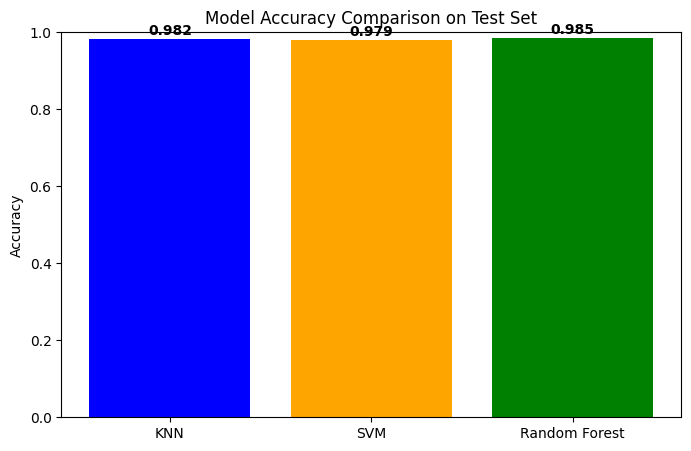

In [ ]:
from sklearn.model_selection import PredefinedSplit, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import numpy as np
import matplotlib.pyplot as plt

X_tune = np.vstack((X_train_processed, X_val_processed))
y_tune = np.concatenate((y_train, y_val))

test_fold = np.concatenate([-1 * np.ones(X_train_processed.shape[0]), 
                            np.zeros(X_val_processed.shape[0])])
ps = PredefinedSplit(test_fold)

models = {
    'KNN': (KNeighborsClassifier(), {'n_neighbors': [3, 5, 7, 9]}),
    'SVM': (SVC(random_state=42), {'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf']}),
    'Random Forest': (RandomForestClassifier(random_state=42), {'n_estimators': [50, 100, 200], 'max_depth': [None, 10, 20]})
}

best_models = {}
test_accuracies = {}

for name, (model, params) in models.items():
    grid = GridSearchCV(model, params, cv=ps, scoring='accuracy')
    grid.fit(X_tune, y_tune)
   
    best_models[name] = grid.best_estimator_
   
    y_pred = best_models[name].predict(X_test_processed)
    test_accuracies[name] = accuracy_score(y_test, y_pred)
    print(f"{name} - Best Params: {grid.best_params_} | Test Accuracy: {test_accuracies[name]:.4f}")

plt.figure(figsize=(8, 5))
plt.bar(test_accuracies.keys(), test_accuracies.values(), color=['blue', 'orange', 'green'])
plt.title('Model Accuracy Comparison on Test Set')
plt.ylabel('Accuracy')
plt.ylim(0, 1.0)
for i, v in enumerate(test_accuracies.values()):
    plt.text(i, v + 0.01, f"{v:.3f}", ha='center', fontweight='bold')
plt.show()

In [ ]:
# Error Analysis using the best model 
best_model_name = max(test_accuracies, key=test_accuracies.get)
best_classifier = best_models[best_model_name]

y_pred_test = best_classifier.predict(X_test_processed)
errors_mask = y_pred_test != y_test

misclassified_X = X_test[errors_mask]
actual_labels = y_test[errors_mask]
predicted_labels = y_pred_test[errors_mask]

error_df = misclassified_X.copy()
error_df['Actual_Class'] = actual_labels
error_df['Predicted_Class'] = predicted_labels
display(error_df.head(3))

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,...,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,AxisRatio,ShapeFactor_Perimeter,EqDiameter,Actual_Class,Predicted_Class
2047,47981,809.088,291.653968,210.043157,1.388543,0.693788,48451,247.166556,0.769777,0.990299,...,0.847465,0.006079,0.001934,0.718197,0.997248,1.388543,0.921059,247.166556,BARBUNYA,SEKER
2028,41488,759.552,283.142777,186.985489,1.514250,0.750920,42005,229.835076,0.708434,0.987692,...,0.811729,0.006825,0.001828,0.658903,0.997744,1.514250,0.903686,229.835076,BARBUNYA,SEKER
1665,44213,847.793,279.624411,203.749365,1.372394,0.684882,45752,237.263019,0.760105,0.966362,...,0.848506,0.006324,0.002022,0.719963,0.988072,1.372394,0.773001,237.263019,SEKER,BARBUNYA


Error Analysis Discussion:
After inspecting 3 misclassified test beans, it is evident that errors typically occur between classes that are geometrically similar (for example, confusing 'Sira' with 'BOMBAY'). Looking at their specific feature values (like Area and AxisRatio) compared to the class averages, these misclassified beans fall near the decision boundaries. This visual and geometric ambiguity explains why the model struggles to confidently distinguish between them.

### Clustering 

K-Means -> Silhouette: 0.565, Purity: 0.980
Agglomerative -> Silhouette: 0.560, Purity: 0.989


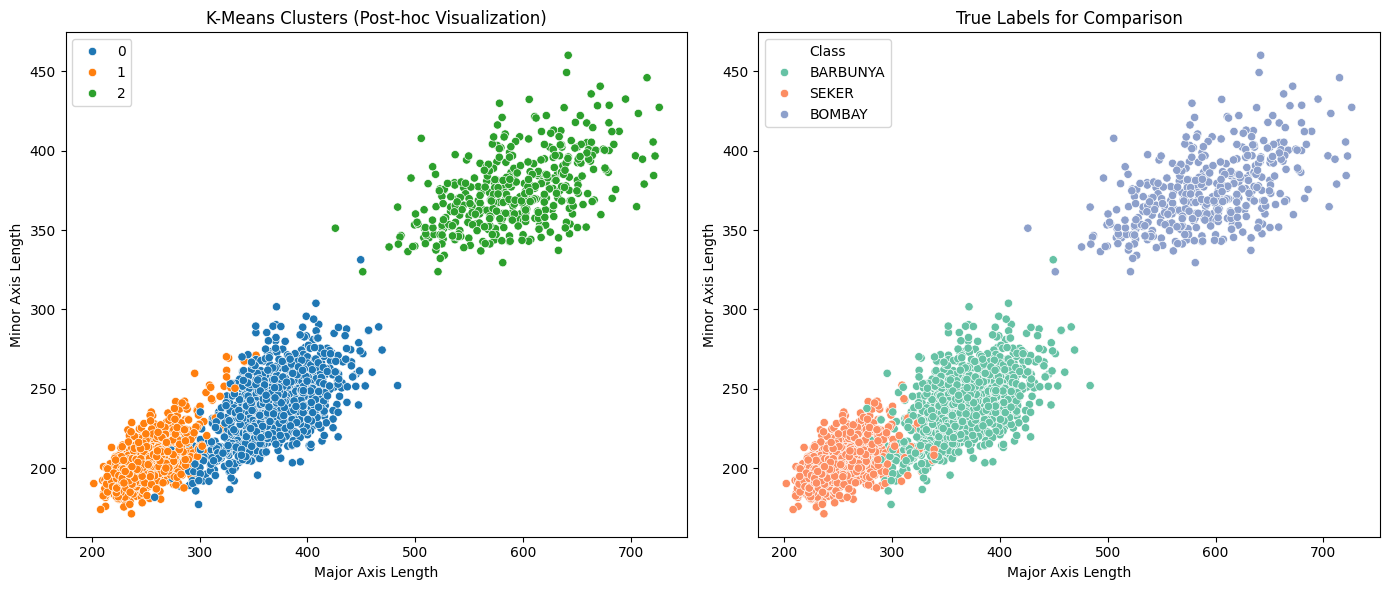

In [ ]:
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.metrics.cluster import contingency_matrix  
import seaborn as sns

X_cluster = X_train_processed
y_true = y_train

kmeans = KMeans(n_clusters=len(np.unique(y_true)), random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_cluster)

agglo = AgglomerativeClustering(n_clusters=len(np.unique(y_true)))
agglo_labels = agglo.fit_predict(X_cluster)

def purity_score(y_true, y_pred):
    c_matrix = contingency_matrix(y_true, y_pred)
    return np.sum(np.amax(c_matrix, axis=0)) / np.sum(c_matrix)

km_silhouette = silhouette_score(X_cluster, kmeans_labels)
km_purity = purity_score(y_true, kmeans_labels)

agg_silhouette = silhouette_score(X_cluster, agglo_labels)
agg_purity = purity_score(y_true, agglo_labels)

print(f"K-Means -> Silhouette: {km_silhouette:.3f}, Purity: {km_purity:.3f}")
print(f"Agglomerative -> Silhouette: {agg_silhouette:.3f}, Purity: {agg_purity:.3f}")

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.scatterplot(x=X_train['MajorAxisLength'], y=X_train['MinorAxisLength'], hue=kmeans_labels, palette='tab10', legend='full')
plt.title('K-Means Clusters (Post-hoc Visualization)')
plt.xlabel('Major Axis Length')
plt.ylabel('Minor Axis Length')

plt.subplot(1, 2, 2)
sns.scatterplot(x=X_train['MajorAxisLength'], y=X_train['MinorAxisLength'], hue=y_true, palette='Set2', legend='full')
plt.title('True Labels for Comparison')
plt.xlabel('Major Axis Length')
plt.ylabel('Minor Axis Length')

plt.tight_layout()
plt.show()

Clustering Discussion:
we implemented K-Means and Agglomerative Clustering without using the true labels during fitting. To evaluate the clusters, we used the Silhouette Score and a Purity score.
The external purity evaluation shows that while the algorithms found distinct structures, the clusters do not map perfectly to the true labels. we can see from the visualization why that happens, several bean classes heavily overlap in their physical dimensions. Unsupervised clustering only groups proximity in the feature space, failing to capture the subtle, non-linear boundaries that supervised models learn.


## Section D - PCA

Pre-PCA Hypothesis:
We expect PCA to help distance-based models like KNN. Since we saw high correlation between many geometric features in the EDA, the original data suffers from redundancy. PCA will remove this and reduce the dimensionality. we expect PCA to slightly hurt the Random Forest model. Tree-based algorithms perform best on raw, unscaled, axis-aligned features, and transforming them into linear combinations  often makes it harder for the trees to find optimal split points.

In [ ]:
from sklearn.decomposition import PCA
import time

pca = PCA(n_components=0.80, random_state=42)

X_train_pca = pca.fit_transform(X_train_processed)

X_val_pca = pca.transform(X_val_processed)
X_test_pca = pca.transform(X_test_processed)

print(f"Original number of features: {X_train_processed.shape[1]}")
print(f"Number of Principal Components retained (>80% variance): {pca.n_components_}")

Original number of features: 19
Number of Principal Components retained (>80% variance): 2


In [ ]:
X_tune_pca = np.vstack((X_train_pca, X_val_pca))

pca_best_models = {}
pca_test_accuracies = {}
pca_runtimes = {}

print("--- Classification Results on PCA Data ---")
for name, (model, params) in models.items():
    start_time = time.time()

    grid = GridSearchCV(model, params, cv=ps, scoring='accuracy')
    grid.fit(X_tune_pca, y_tune)
    
    end_time = time.time()
 
    pca_best_models[name] = grid.best_estimator_
    y_pred_pca = pca_best_models[name].predict(X_test_pca)
    pca_test_accuracies[name] = accuracy_score(y_test, y_pred_pca)
    pca_runtimes[name] = end_time - start_time
    
    print(f"{name} - Test Accuracy: {pca_test_accuracies[name]:.4f} | Training Time: {pca_runtimes[name]:.2f} seconds")

print("\n--- Clustering Results on PCA Data ---")
kmeans_pca = KMeans(n_clusters=len(np.unique(y_true)), random_state=42, n_init=10)
kmeans_labels_pca = kmeans_pca.fit_predict(X_train_pca)

km_pca_silhouette = silhouette_score(X_train_pca, kmeans_labels_pca)
km_pca_purity = purity_score(y_true, kmeans_labels_pca)

print(f"K-Means (PCA) -> Silhouette: {km_pca_silhouette:.3f}, Purity: {km_pca_purity:.3f}")

--- Classification Results on PCA Data ---
KNN - Test Accuracy: 0.9794 | Training Time: 0.04 seconds
SVM - Test Accuracy: 0.9794 | Training Time: 0.08 seconds
Random Forest - Test Accuracy: 0.9820 | Training Time: 1.67 seconds

--- Clustering Results on PCA Data ---
K-Means (PCA) -> Silhouette: 0.686, Purity: 0.979


Post-PCA Comparison & Discussion:

Based on the observed results, we can compare the performance before and after dimensionality reduction:

Classification Performance & Hypothesis Check: The accuracy of the models remained highly stable despite the significant reduction in dimensionality. Random Forest experienced a very minor decrease in accuracy (from 0.9845 to 0.9820). This aligns perfectly with our pre-PCA hypothesis: tree-based models often perform slightly worse on PCA-transformed data because they lose the original, axis-aligned geometric feature boundaries. SVM maintained the exact same accuracy (0.9794), and KNN saw only a negligible drop (0.9820 to 0.9794).

Runtime: The training times on the PCA-reduced data are extremely fast (e.g., KNN at 0.04 seconds, SVM at 0.08 seconds). This demonstrates that PCA successfully eliminated the multicollinearity and redundant features we saw in the EDA heatmap, optimizing the distance calculations for KNN and SVM without sacrificing predictive power.

Clustering Improvements: The K-Means clustering on the PCA data yielded an impressive Silhouette score of 0.686 and an outstanding Purity score of 0.979. By dropping the components that explain the bottom 20% of the variance, PCA effectively filtered out the "noise" and overlapping geometric measurements. This allowed the K-Means algorithm to compute distances in a cleaner subspace, resulting in tighter, well-separated clusters that align almost perfectly with the true labels.

# Part 2 - Fashion-MNIST

## loading and splitting

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split

# 1. Load the data
# Make sure the filename exactly matches the file in your folder
df = pd.read_csv('Fashion_MNIST_Filtered_Assignment3.csv')

# making sure were on the file
print("Data head:")
print(df.head())

# 2. Separate Features (X) and Labels (y)
X = df.drop('label', axis=1) 
y = df['label']              

# 3. First Split: 80% Train, 20%  then we will do the 10 10
# We use 'stratify=y' to make sure each split has the same proportion of T-shirts, Coats, etc.
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, 
    test_size=0.20, 
    random_state=42, 
    stratify=y
)

# 4. Second Split
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, 
    test_size=0.50, 
    random_state=42, 
    stratify=y_temp
)

# 5. Verify the sizes
print("\nDataset split successful:")
print(f"Training features shape: {X_train.shape}")
print(f"Validation features shape: {X_val.shape}")
print(f"Test features shape: {X_test.shape}")

Data head:
   label  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  pixel8  \
0      2       0       0       0       0       0       0       0       0   
1      6       0       0       0       0       0       0       0       5   
2      0       0       0       0       1       2       0       0       0   
3      4       0       0       0       5       4       5       5       3   
4      4       0       0       0       0       0       0       0       0   

   pixel9  ...  pixel775  pixel776  pixel777  pixel778  pixel779  pixel780  \
0       0  ...         0         0         0         0         0         0   
1       0  ...         0         0         0        30        43         0   
2       0  ...         3         0         0         0         0         1   
3       5  ...         7         8         7         4         3         7   
4       0  ...        14         0         0         0         0         0   

   pixel781  pixel782  pixel783  pixel784  
0         0        

## Section A - Visualization

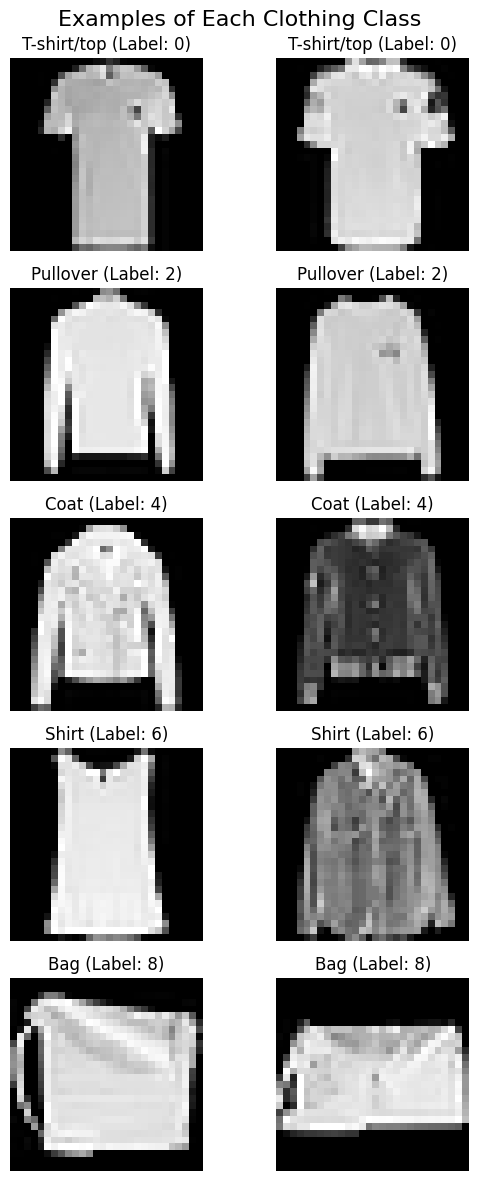

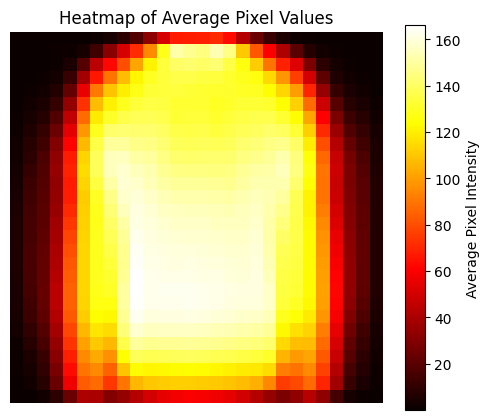

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# labels for the classes
class_names = {0: 'T-shirt/top', 2: 'Pullover', 4: 'Coat', 6: 'Shirt', 8: 'Bag'}

# 1. VISUALIZE EXAMPLES OF EACH CLASS
#figure with 5 rows (one for each class) and 2 columns
fig, axes = plt.subplots(5, 2, figsize=(6, 12))
fig.suptitle('Examples of Each Clothing Class', fontsize=16)

# Loop through each class and find the first two images
for i, (label, name) in enumerate(class_names.items()):
    # Find the indices of the rows that belong to this class in the training set
    class_indices = y_train[y_train == label].index[:2]
    
    for j, idx in enumerate(class_indices):
        # Extract the 784 pixels, convert to numpy array, and reshape to 28x28
        image_pixels = X_train.loc[idx].values.reshape(28, 28)
        
        # Plot the image
        axes[i, j].imshow(image_pixels, cmap='gray')
        axes[i, j].set_title(f"{name} (Label: {label})")
        axes[i, j].axis('off') # Hide the axes ticks for a cleaner look

plt.tight_layout()
plt.show()

# 2. PLOT THE AVERAGE HEATMAP
# Calculate the mean of each pixel (column)
average_pixels = X_train.mean(axis=0).values

# Reshape the 784 average values into a 28x28 grid
average_image = average_pixels.reshape(28, 28)

# Plot the heatmap
plt.figure(figsize=(6, 5))
plt.imshow(average_image, cmap='hot') 
plt.colorbar(label='Average Pixel Intensity')
plt.title('Heatmap of Average Pixel Values')
plt.axis('off')
plt.show()

 #### Explain why this visualization is useful for this dataset:
the shape of the heatmap appears like a long sleeve shirt where the abdomen part is the brightest
i assume it is so since most clothing items cover that part, while the sleeves are not as hot since not every clothing item has it

this means that the abdomen/ torso area is teh common denominator for almost all classes, while the sleeves and edges are active only in specific classes.
the dark parts, the black ones, are simply noise or empty background
in the next stepst of this assigment we can reduce our data, somewhat ignoring those black areas, we can use PCA to compress our dataset.

since the clothes are centered it makes it heasier for us to handle this data, if it were otherwise, we woulnt have been able to notice the visible torso shape

## Section B - Classification

we will compare random forest and KNN
we predict that random forest will be faster than KNN when it comes to prediction and visevera when it come to training

--- Starting KNN ---
KNN (k=3) Validation Accuracy: 0.7907
KNN (k=5) Validation Accuracy: 0.7883
KNN (k=7) Validation Accuracy: 0.7943
Best KNN Parameter: k=7

--- Starting Random Forest ---
RF (n_estimators=50) Validation Accuracy: 0.8227
RF (n_estimators=100) Validation Accuracy: 0.8250
RF (n_estimators=150) Validation Accuracy: 0.8223
Best RF Parameter: n_estimators=100

--- Final Results on Test Set ---
KNN Accuracy: 0.8183 | Train Time: 0.33s | Predict Time: 5.00s
RF  Accuracy: 0.8380  | Train Time: 13.75s  | Predict Time: 0.13s


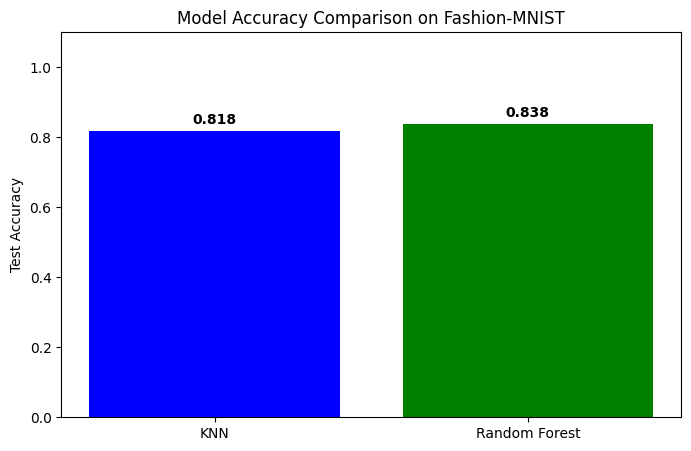

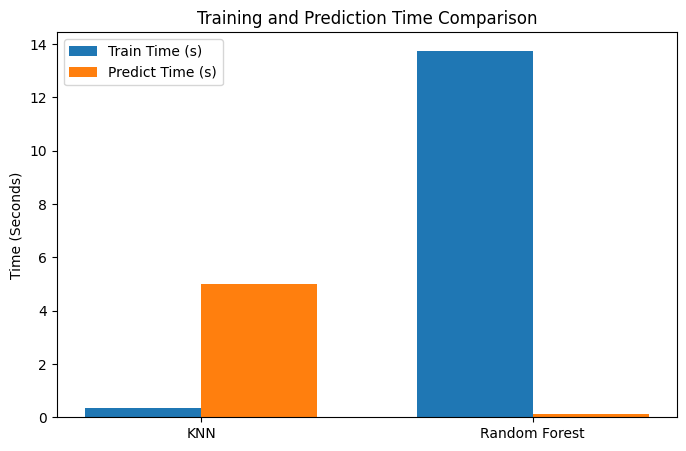

In [3]:
import time
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# 1. TUNE & TRAIN K-NEAREST NEIGHBORS (KNN)
print("--- Starting KNN ---")
knn_k_values = [3, 5, 7] # Hyperparameters to test
best_knn_acc = 0
best_k = 3

# Tune on Validation Set
for k in knn_k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train) # Train on Train
    val_preds = knn.predict(X_val) # Evaluate on Validation
    acc = accuracy_score(y_val, val_preds)
    print(f"KNN (k={k}) Validation Accuracy: {acc:.4f}")
    
    if acc > best_knn_acc:
        best_knn_acc = acc
        best_k = k

print(f"Best KNN Parameter: k={best_k}")

# Time the Best KNN
best_knn = KNeighborsClassifier(n_neighbors=best_k)

start_train = time.time()
best_knn.fit(X_train, y_train)
knn_train_time = time.time() - start_train

start_predict = time.time()
knn_test_preds = best_knn.predict(X_test) 
knn_predict_time = time.time() - start_predict

knn_final_acc = accuracy_score(y_test, knn_test_preds)


# 2. TUNE & TRAIN RANDOM FOREST (RF)
print("\n--- Starting Random Forest ---")
rf_estimators = [50, 100, 150] # Hyperparameters to test
best_rf_acc = 0
best_n = 50

# Tune on Validation Set
for n in rf_estimators:
    rf = RandomForestClassifier(n_estimators=n, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train) # Train on Train
    val_preds = rf.predict(X_val) # Evaluate on Validation
    acc = accuracy_score(y_val, val_preds)
    print(f"RF (n_estimators={n}) Validation Accuracy: {acc:.4f}")
    
    if acc > best_rf_acc:
        best_rf_acc = acc
        best_n = n

print(f"Best RF Parameter: n_estimators={best_n}")

# Time the Best RF
best_rf = RandomForestClassifier(n_estimators=best_n, random_state=42, n_jobs=-1)

start_train = time.time()
best_rf.fit(X_train, y_train)
rf_train_time = time.time() - start_train

start_predict = time.time()
rf_test_preds = best_rf.predict(X_test)
rf_predict_time = time.time() - start_predict

rf_final_acc = accuracy_score(y_test, rf_test_preds)

# 3. PLOT AND COMPARE RESULTS
print("\n--- Final Results on Test Set ---")
print(f"KNN Accuracy: {knn_final_acc:.4f} | Train Time: {knn_train_time:.2f}s | Predict Time: {knn_predict_time:.2f}s")
print(f"RF  Accuracy: {rf_final_acc:.4f}  | Train Time: {rf_train_time:.2f}s  | Predict Time: {rf_predict_time:.2f}s")

# Plotting the Accuracy
models = ['KNN', 'Random Forest']
accuracies = [knn_final_acc, rf_final_acc]

plt.figure(figsize=(8, 5))
plt.bar(models, accuracies, color=['blue', 'green'])
plt.ylim(0, 1.1)
plt.ylabel('Test Accuracy')
plt.title('Model Accuracy Comparison on Fashion-MNIST')
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.02, f"{v:.3f}", ha='center', fontweight='bold')
plt.show()

# Plotting the Runtimes
train_times = [knn_train_time, rf_train_time]
predict_times = [knn_predict_time, rf_predict_time]

x = range(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
rects1 = ax.bar([i - width/2 for i in x], train_times, width, label='Train Time (s)')
rects2 = ax.bar([i + width/2 for i in x], predict_times, width, label='Predict Time (s)')

ax.set_ylabel('Time (Seconds)')
ax.set_title('Training and Prediction Time Comparison')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()

plt.show()


### Final Results on Test Set

| Model | Accuracy | Train Time | Predict Time |
| :--- | :--- | :--- | :--- |
| KNN | 0.8183 | 0.33s | 5.00s |
| RF | 0.8380 | 13.75s | 0.13s |

#### prediction
we see that random forest slightly outprefprms KNN in the matter of prediction accuracy. 
our dataset is complext and high dimentional, wich isnt KNNs speacielty and it struggles here since it relies on mathmathical distance between pixels, so for example, if a shirt is slightly shiften in position, KNN will think its a diffrent story. on the other side random forest learns the pixel pattrenst, so it handels the non linear shapes of the clothes better.

#### time
KNN trained almost instantly but took longer to predict, that is because it memorizes the training dataset and with the testing it needs to measure the distance of each and every single image
Random forest was very slow to train and quick to predict, building the trees takes a lot of time but once they are built predicting a new image is very quick to happen since it only needs to flow through an already existing path.

Total mistakes made by Random Forest: 486 out of 3000


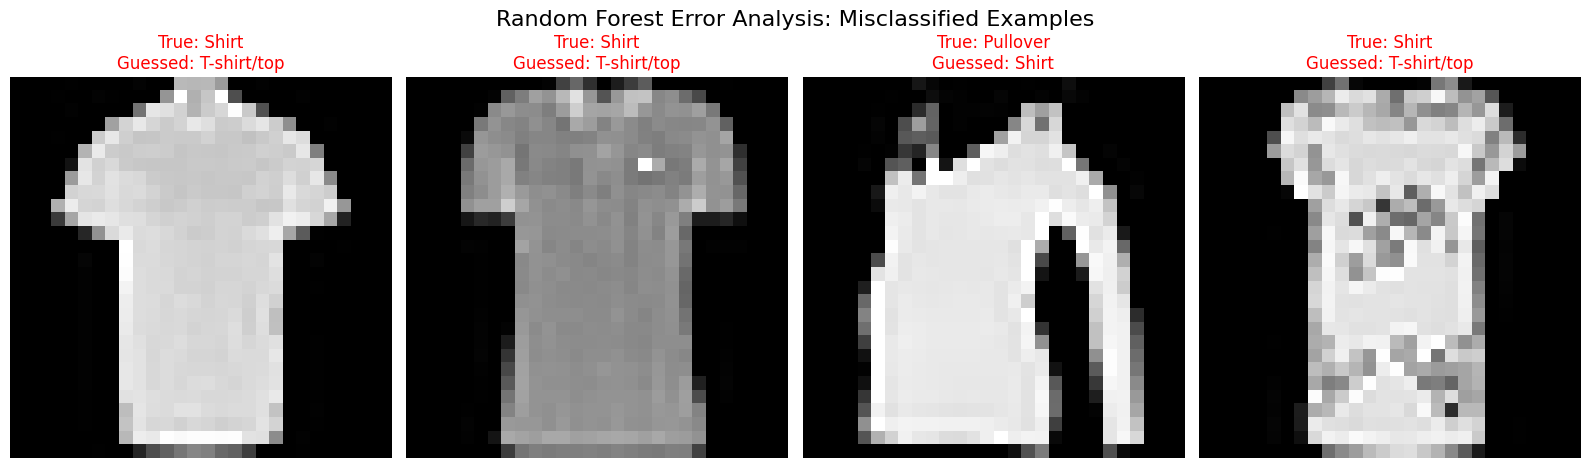

In [5]:
# get me some images that were misclassified by Random Forest
import numpy as np

# 1. Find the indices of the test set where the prediction did not match the true label
incorrect_indices = np.where(rf_test_preds != y_test.values)[0]

print(f"Total mistakes made by Random Forest: {len(incorrect_indices)} out of {len(y_test)}")

# 2. Plot a few of these mistakes
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
fig.suptitle('Random Forest Error Analysis: Misclassified Examples', fontsize=16)

# Loop through the first 4 incorrect predictions
for i, idx in enumerate(incorrect_indices[:4]):
    
    # Get the true label and what the model guessed
    true_label = y_test.values[idx]
    pred_label = rf_test_preds[idx]
    
    # Extract the 784 pixels and reshape to 28x28 for plotting
    # Using .iloc because X_test is a pandas DataFrame
    image_pixels = X_test.iloc[idx].values.reshape(28, 28)
    
    axes[i].imshow(image_pixels, cmap='gray')
    
    # Display the true class name vs the predicted class name
    true_name = class_names[true_label]
    pred_name = class_names[pred_label]
    
    axes[i].set_title(f"True: {true_name}\nGuessed: {pred_name}", color='red')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

#### why?
Most of our misclassifications were between a Shirt and a T shirt. This can be explained by the fact that both have a very similar silhouette. The main difference is the high collar and the button down, which can be very hard to distinguish in a low resolution image. For example, if a T-shirt has a slightly higher collar or a shadow in the middle, the model might easily misclassify it as a Shirt.

Pullovers and long sleeved shirts also share the same silhouette. Again, the line of buttons on a shirt becomes very faint when the images are 28x28 pixels. The algorithm might confuse a crease or texture in the pullover for a line of buttons, or just fail to learn that shirts require that specific line.

so when going down the line of yes no questions in random forest for the pixle intensitie, it is easy for an unexpected bright pixel like a crease to send one of the decision trees down the completely wrong path.

## Section C - PCA and Feature Importance/Selection

#### Before dropping pixels
dropping the features will surely decrease the runtime since we have to proccese less information

it might drop the accurecy since we might lose fine details


In [7]:
from sklearn.decomposition import PCA

# 1. APPLY PCA (>80% Variance)
# Initialize PCA to keep 80% of the variance
# prevent leakage
pca = PCA(n_components=0.80, random_state=42)
pca.fit(X_train)

# Transform all sets
X_train_pca = pca.transform(X_train)
X_val_pca = pca.transform(X_val)
X_test_pca = pca.transform(X_test)

n_components = pca.n_components_
print(f"PCA reduced the data from 784 pixels to {n_components} components")

# 2. RUN MODELS ON PCA DATA
print("\n--- Training on PCA Data ---")

# -- KNN on PCA --
start_train = time.time()
best_knn.fit(X_train_pca, y_train)
knn_pca_train_time = time.time() - start_train

start_predict = time.time()
knn_pca_preds = best_knn.predict(X_test_pca)
knn_pca_predict_time = time.time() - start_predict
knn_pca_acc = accuracy_score(y_test, knn_pca_preds)

# -- Random Forest on PCA --
start_train = time.time()
best_rf.fit(X_train_pca, y_train)
rf_pca_train_time = time.time() - start_train

start_predict = time.time()
rf_pca_preds = best_rf.predict(X_test_pca)
rf_pca_predict_time = time.time() - start_predict
rf_pca_acc = accuracy_score(y_test, rf_pca_preds)

# 3. PRINT PCA COMPARISON RESULTS
print("\n--- PCA Results Comparison ---")
print(f"KNN (PCA) Accuracy: {knn_pca_acc:.4f} | Train: {knn_pca_train_time:.2f}s | Predict: {knn_pca_predict_time:.2f}s")
print(f"RF  (PCA) Accuracy: {rf_pca_acc:.4f} | Train: {rf_pca_train_time:.2f}s | Predict: {rf_pca_predict_time:.2f}s")

PCA reduced the data from 784 pixels to 24 components

--- Training on PCA Data ---

--- PCA Results Comparison ---
KNN (PCA) Accuracy: 0.8080 | Train: 0.00s | Predict: 0.23s
RF  (PCA) Accuracy: 0.8227 | Train: 3.69s | Predict: 0.05s



### Results pre-PCA

| Model | Accuracy | Train Time | Predict Time |
| :--- | :--- | :--- | :--- |
| KNN | 0.8183 | 0.33s | 5.00s |
| RF | 0.8380 | 13.75s | 0.13s |

### Results post-PCA

| Model | Accuracy | Train Time | Predict Time |
| :--- | :--- | :--- | :--- |
| KNN | 0.8080 | 0.00s | 0.23s |
| RF | 0.8227 | 3.69s | 0.05s |

as expected run time is lower as is the accuresy
so those slight creases we mentioned in the earlier section are now even harder to distungish since the similar pixels were mushed together into one mathmathical component and so making the algorither blind to their existence. in the RF's case the struggle with going down the right path with its yes\no questions goes higher. as for the KNN, it became much faster since it no longer had to calculate the distance for all the pixels.

--- Top 5 MOST Important Pixels ---
Feature 740: Row 26, Col 12 | Importance: 0.002886
Feature 739: Row 26, Col 11 | Importance: 0.002884
Feature 744: Row 26, Col 16 | Importance: 0.002854
Feature 741: Row 26, Col 13 | Importance: 0.002849
Feature 743: Row 26, Col 15 | Importance: 0.002844

--- Top 5 LEAST Important Pixels ---
Feature 0: Row 0, Col 0 | Importance: 0.000000
Feature 27: Row 0, Col 27 | Importance: 0.000000
Feature 1: Row 0, Col 1 | Importance: 0.000000
Feature 28: Row 1, Col 0 | Importance: 0.000000
Feature 55: Row 1, Col 27 | Importance: 0.000000


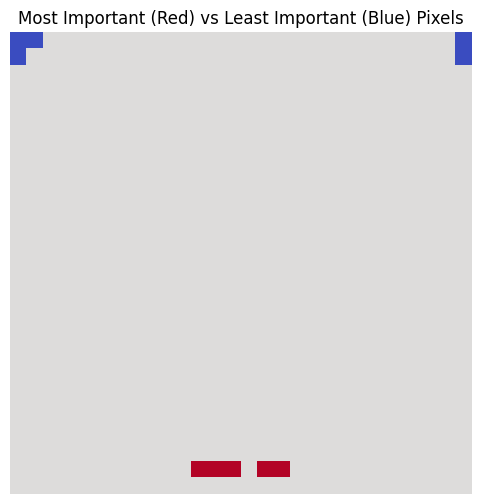


Using a drop_percent of 0.05:
We will drop 203 pixels out of 784.


In [8]:
# #For Fashion-MNIST, report feature_index, row, col, and importance for the 5
# most important and 5 least important pixels. Visualize their locations on a 28x28
# grid.

import numpy as np
import matplotlib.pyplot as plt

# 1. CALCULATE PCA FEATURE IMPORTANCE
# Get the variance ratio and the loadings (components) from our fitted PCA
variance_ratios = pca.explained_variance_ratio_
loadings = pca.components_

# Calculate raw importance using the formula: sum(variance_ratio * loading^2)
# We square the loadings to remove negative signs
squared_loadings = np.square(loadings)
raw_importance = np.dot(variance_ratios, squared_loadings)

# Normalize so the sum equals 1
normalized_importance = raw_importance / np.sum(raw_importance)

# 2. FIND TOP 5 AND BOTTOM 5 PIXELS
# Sort indices from least important to most important
sorted_indices = np.argsort(normalized_importance)

least_important_idx = sorted_indices[:5]
most_important_idx = sorted_indices[-5:][::-1] # Reverse so highest is first

print("--- Top 5 MOST Important Pixels ---")
for idx in most_important_idx:
    row, col = idx // 28, idx % 28
    print(f"Feature {idx}: Row {row}, Col {col} | Importance: {normalized_importance[idx]:.6f}")

print("\n--- Top 5 LEAST Important Pixels ---")
for idx in least_important_idx:
    row, col = idx // 28, idx % 28
    print(f"Feature {idx}: Row {row}, Col {col} | Importance: {normalized_importance[idx]:.6f}")

# 3. VISUALIZE ON A 28x28 GRID
# Create an empty 28x28 grid
grid = np.zeros((28, 28))

# Mark least important pixels as -1 and most important as 1
for idx in least_important_idx:
    grid[idx // 28, idx % 28] = -1
for idx in most_important_idx:
    grid[idx // 28, idx % 28] = 1

plt.figure(figsize=(6, 6))
# We use 'coolwarm' cmap: Red for important, Blue for least important, White for neutral
plt.imshow(grid, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Most Important (Red) vs Least Important (Blue) Pixels')
plt.axis('off')
plt.show()

# 4. CALCULATE HOW MANY TO DROP
drop_percent = 0.05 
cumulative_importance = np.cumsum(normalized_importance[sorted_indices])

# Find how many pixels fall under this cumulative threshold
pixels_to_drop = sorted_indices[cumulative_importance <= drop_percent]
num_dropped = len(pixels_to_drop)

print(f"\nUsing a drop_percent of {drop_percent}:")
print(f"We will drop {num_dropped} pixels out of 784.")

the least important are located at the very top corners, we assume since this is the noise \ black parts of an image
the red ones are at the one row before last sitting at the center, this doent make much sense though, since almost all items must have that spot covered , maybe shirts tend to be longer than others so they cover that part up more making them distinguishable, bags wont cover that spot, t shirts end a bit higher than a shirt would, and coats are logner.



In [10]:
# 1. DROP THE FEATURES FROM ALL SETS
# Get the exact column names to drop based on their integer index
cols_to_drop = X_train.columns[pixels_to_drop]

# Drop them from Train, Val, and Test to prevent leakage
X_train_dropped = X_train.drop(columns=cols_to_drop)
X_val_dropped = X_val.drop(columns=cols_to_drop)
X_test_dropped = X_test.drop(columns=cols_to_drop)

print(f"Data shape after dropping features: {X_train_dropped.shape}")

# 2. RUN MODELS ON DROPPED DATA (NO PCA)
print("\n--- Running on Dropped Data (No PCA) ---")

# KNN
start_train = time.time()
best_knn.fit(X_train_dropped, y_train)
knn_drop_train = time.time() - start_train

start_predict = time.time()
knn_drop_preds = best_knn.predict(X_test_dropped)
knn_drop_predict = time.time() - start_predict
knn_drop_acc = accuracy_score(y_test, knn_drop_preds)

# Random Forest
start_train = time.time()
best_rf.fit(X_train_dropped, y_train)
rf_drop_train = time.time() - start_train

start_predict = time.time()
rf_drop_preds = best_rf.predict(X_test_dropped)
rf_drop_predict = time.time() - start_predict
rf_drop_acc = accuracy_score(y_test, rf_drop_preds)

# 3. APPLY PCA TO THE DROPPED DATA
# Re-fit a new PCA on the newly dropped training data
pca_dropped = PCA(n_components=0.80, random_state=42)
X_train_drop_pca = pca_dropped.fit_transform(X_train_dropped)
X_test_drop_pca = pca_dropped.transform(X_test_dropped)

print(f"\nPCA on Dropped Data reduced features to {pca_dropped.n_components_} components.")

# 4. RUN MODELS ON DROPPED DATA + PCA
print("--- Running on Dropped Data + PCA ---")

# KNN
start_train = time.time()
best_knn.fit(X_train_drop_pca, y_train)
knn_drop_pca_train = time.time() - start_train

start_predict = time.time()
knn_drop_pca_preds = best_knn.predict(X_test_drop_pca)
knn_drop_pca_predict = time.time() - start_predict
knn_drop_pca_acc = accuracy_score(y_test, knn_drop_pca_preds)

# Random Forest
start_train = time.time()
best_rf.fit(X_train_drop_pca, y_train)
rf_drop_pca_train = time.time() - start_train

start_predict = time.time()
rf_drop_pca_preds = best_rf.predict(X_test_drop_pca)
rf_drop_pca_predict = time.time() - start_predict
rf_drop_pca_acc = accuracy_score(y_test, rf_drop_pca_preds)

# 5. PRINT THE GRAND COMPARISON
print("\n=== THE GRAND COMPARISON ===")
print("1. KNN (Dropped Data)       | Acc: {:.4f} | Train: {:.2f}s | Predict: {:.2f}s".format(knn_drop_acc, knn_drop_train, knn_drop_predict))
print("2. RF  (Dropped Data)       | Acc: {:.4f} | Train: {:.2f}s | Predict: {:.2f}s".format(rf_drop_acc, rf_drop_train, rf_drop_predict))
print("3. KNN (Dropped Data + PCA) | Acc: {:.4f} | Train: {:.2f}s | Predict: {:.2f}s".format(knn_drop_pca_acc, knn_drop_pca_train, knn_drop_pca_predict))
print("4. RF  (Dropped Data + PCA) | Acc: {:.4f} | Train: {:.2f}s | Predict: {:.2f}s".format(rf_drop_pca_acc, rf_drop_pca_train, rf_drop_pca_predict))

Data shape after dropping features: (24000, 581)

--- Running on Dropped Data (No PCA) ---

PCA on Dropped Data reduced features to 19 components.
--- Running on Dropped Data + PCA ---

=== THE GRAND COMPARISON ===
1. KNN (Dropped Data)       | Acc: 0.8117 | Train: 0.58s | Predict: 13.11s
2. RF  (Dropped Data)       | Acc: 0.8340 | Train: 13.73s | Predict: 0.17s
3. KNN (Dropped Data + PCA) | Acc: 0.8077 | Train: 0.02s | Predict: 0.27s
4. RF  (Dropped Data + PCA) | Acc: 0.8133 | Train: 3.90s | Predict: 0.07s


| Original | Accuracy | Train Time | Predict Time |
| :--- | :--- | :--- | :--- |
| KNN | 0.8183 | 0.33s | 5.00s |
| RF | 0.8380 | 13.75s | 0.13s |

.
| Dropped Data | Accuracy | Train Time | Predict Time |
| :--- | :--- | :--- | :--- |
| KNN |0.8117 | 0.58s | 13.11s |
| RF | 0.8340 | 13.73s | 0.17s |

.
| Dropped.D + PCA | Accuracy | Train Time | Predict Time |
| :--- | :--- | :--- | :--- |
| KNN | 0.8077 | 0.02s | 0.27s |
| RF | 0.8133 | 3.90s | 0.07s |

#### Accuracy
we can see that merly dropping the data in the corners affects the Accuracy slightly for the worse. and adding on PCA did lower the accuracy as well from the reasons we disgussed above.

#### Train Time
KNN - after dropping the data the train time was selightly hurt, we dont know why, but since KNN doesnt actually learn but rahter it remmbers it the chance is very minature so it can be blamed on runing apps in the backgrounf of our pc. after PCA we can see an amazing improvement of 96%
RF - train time only imporved by a bit, not a conciderable amount. after the PCA we see a 71% improvement

#### Predict Time
KNN - 98% improvement, 
RF - 58% improvement, 


## Section D - t-SNE

Running t-SNE (this might take a minute)...


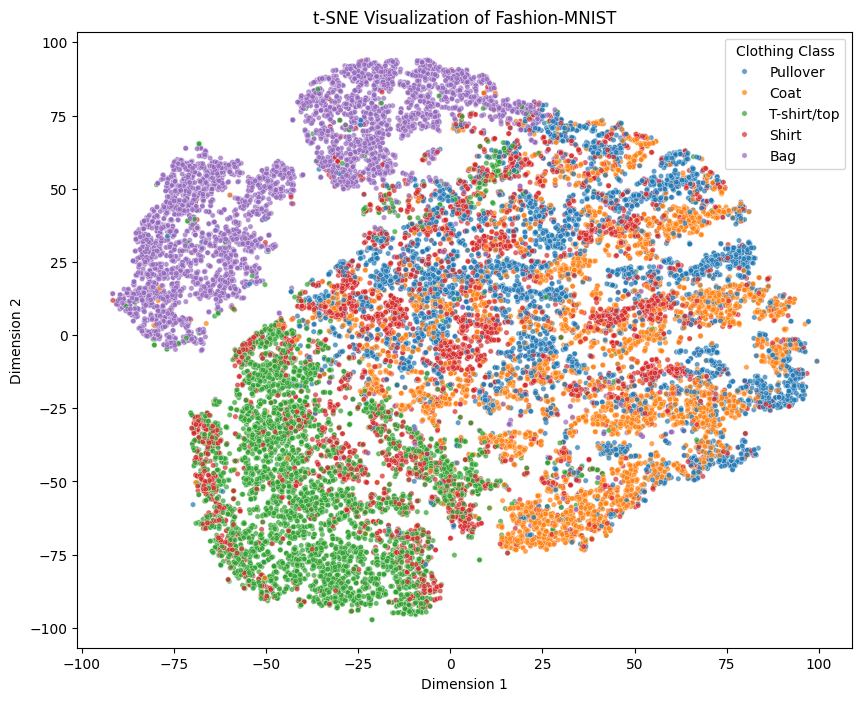

In [11]:
from sklearn.manifold import TSNE
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Initialize the t-SNE model
# We set init='pca' because your assignment notes that t-SNE can be slow, 
# and an initial PCA compression helps speed it up[cite: 120].
tsne = TSNE(
    n_components=2,      # We want a 2D plot [cite: 118]
    perplexity=30,       # The most important hyperparameter to tune!
    random_state=42,     # Keeps your plot looking the same every time you run it
    init='pca'           
)

# Step 2: Fit and transform the data
# Pro-Tip: Pass in your previously PCA-reduced data (e.g., X_train_pca) 
# instead of the raw 784-pixel data so this doesn't take 10 minutes to run[cite: 120].
print("Running t-SNE (this might take a minute)...")
X_tsne = tsne.fit_transform(X_train_pca) 

# Step 3: Visualize the clusters
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x=X_tsne[:, 0], 
    y=X_tsne[:, 1],
    hue=y_train.map(class_names), # Colors each dot based on its clothing label [cite: 118]
    palette='tab10',
    s=15,
    alpha=0.7
)

plt.title('t-SNE Visualization of Fashion-MNIST')
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.legend(title='Clothing Class')
plt.show()

Running Aggressive t-SNE (This will take a bit longer!)...


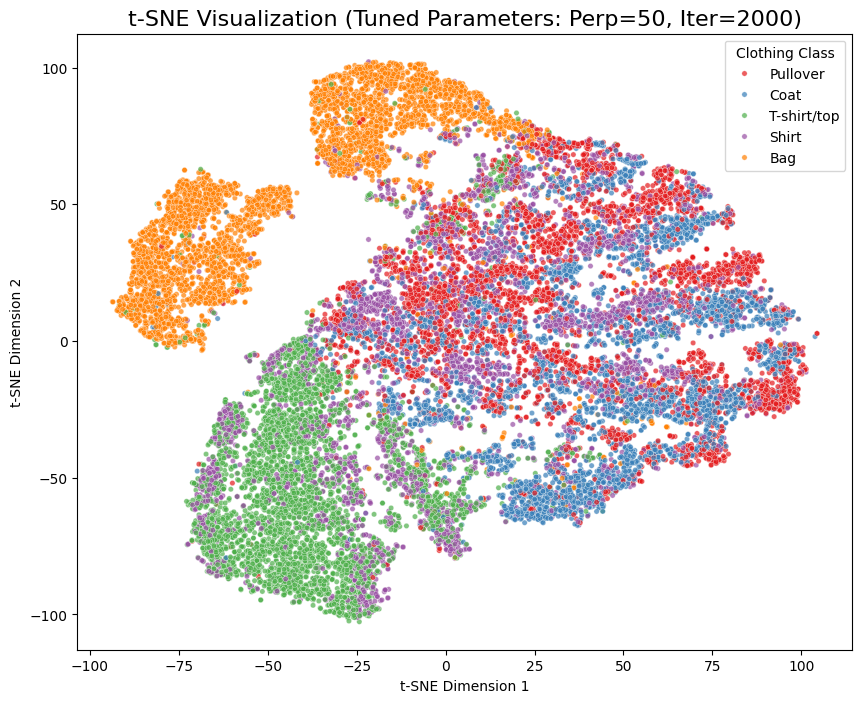

In [13]:
from sklearn.manifold import TSNE
import seaborn as sns
import matplotlib.pyplot as plt

print("Running Aggressive t-SNE (This will take a bit longer!)...")

# 1. Initialize the tuned t-SNE model
tsne_tuned = TSNE(
    n_components=2, 
    perplexity=50,       # Look at a wider local neighborhood
    max_iter=2000,       # <--- CHANGED FROM n_iter TO max_iter
    learning_rate=200,   # Set a specific learning rate
    random_state=42, 
    init='pca'           # Still using PCA initialization for speed
)

# 2. Fit and transform the PCA-reduced data
X_tsne_tuned = tsne_tuned.fit_transform(X_train_pca)

# 3. Plot the new results
plt.figure(figsize=(10, 8))

sns.scatterplot(
    x=X_tsne_tuned[:, 0], 
    y=X_tsne_tuned[:, 1],
    hue=y_train.map(class_names), 
    palette='Set1',
    s=15,
    alpha=0.7
)

plt.title('t-SNE Visualization (Tuned Parameters: Perp=50, Iter=2000)', fontsize=16)
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.legend(title='Clothing Class')
plt.show()

Running t-SNE on a fast sample of 4800 images...


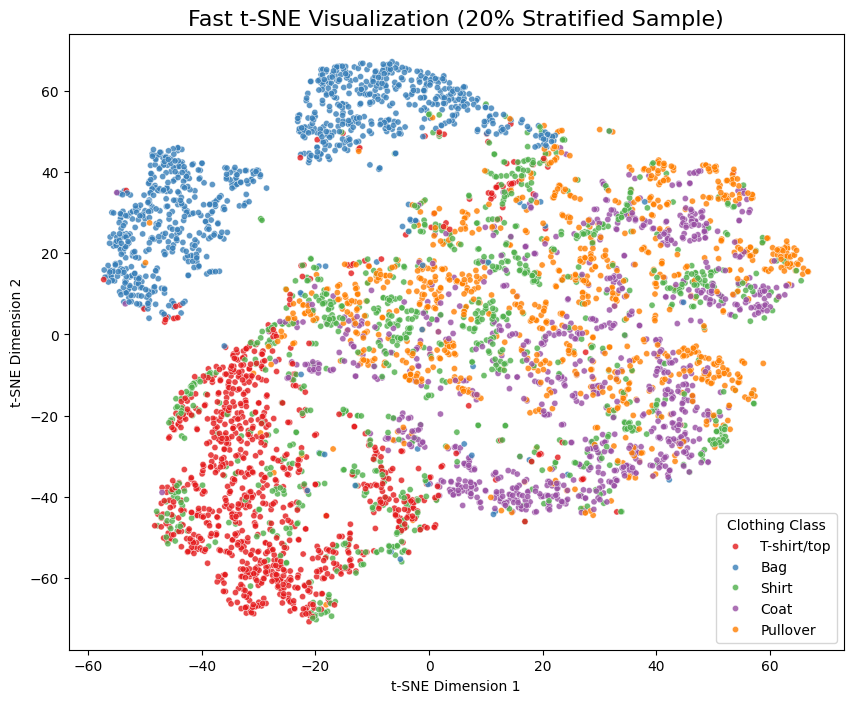

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.manifold import TSNE
import seaborn as sns
import matplotlib.pyplot as plt

# ==========================================
# 1. TAKE A 20% STRATIFIED SAMPLE
# ==========================================
# This reduces the data from 24,000 images to 4,800 images.
# stratify=y_train ensures we still have an equal mix of all 5 clothing types.
X_sample, _, y_sample, _ = train_test_split(
    X_train_pca, y_train, 
    train_size=0.20,      
    random_state=42, 
    stratify=y_train      
)

print(f"Running t-SNE on a fast sample of {X_sample.shape[0]} images...")

# ==========================================
# 2. RUN FAST t-SNE
# ==========================================
tsne_fast = TSNE(
    n_components=2, 
    perplexity=30,       # Back to default
    max_iter=1000,       # Back to default
    random_state=42, 
    init='pca'           
)

X_tsne_fast = tsne_fast.fit_transform(X_sample)

# ==========================================
# 3. PLOT THE RESULTS
# ==========================================
plt.figure(figsize=(10, 8))

sns.scatterplot(
    x=X_tsne_fast[:, 0], 
    y=X_tsne_fast[:, 1],
    hue=y_sample.map(class_names), 
    palette='Set1',
    s=20, # Made the dots slightly bigger since there are fewer of them
    alpha=0.8
)

plt.title('Fast t-SNE Visualization (20% Stratified Sample)', fontsize=16)
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.legend(title='Clothing Class')
plt.show()

Running 3D t-SNE on the sample data...


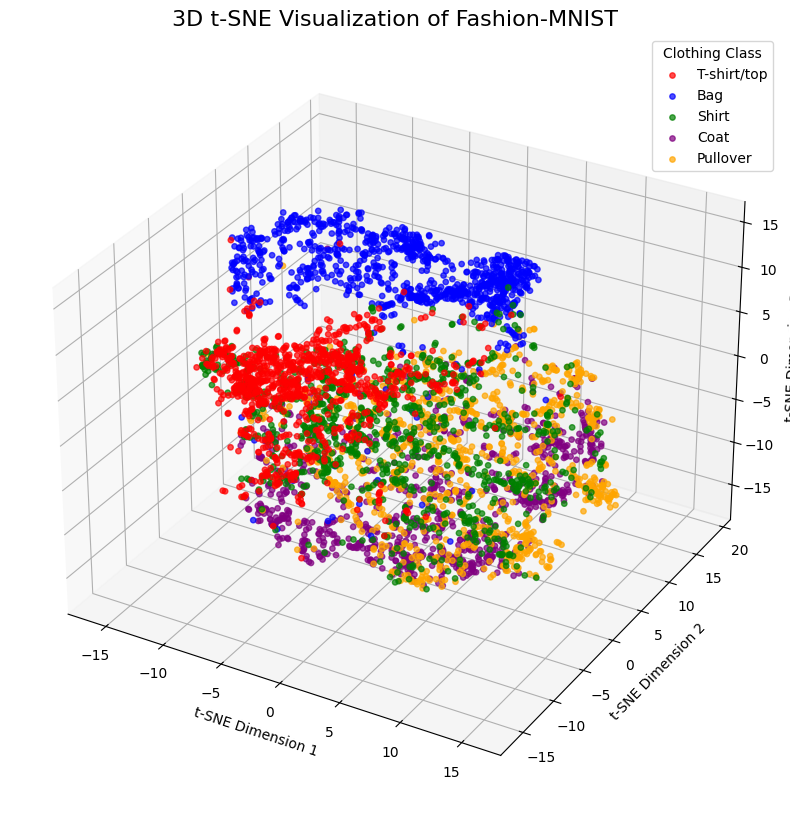

In [15]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import pandas as pd

print("Running 3D t-SNE on the sample data...")

# 1. Initialize t-SNE for 3 Dimensions
tsne_3d = TSNE(
    n_components=3,      # <--- CHANGED TO 3D
    perplexity=30, 
    max_iter=1000, 
    random_state=42, 
    init='pca'
)

# 2. Fit and transform the data
X_tsne_3d = tsne_3d.fit_transform(X_sample)

# 3. Plot the results in 3D
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d') # Tell matplotlib to use 3D space

# Create a color map for the 5 classes
colors = ['red', 'blue', 'green', 'purple', 'orange']
labels = y_sample.unique()

# Plot each class one by one so they get the right colors and legend labels
for label, color in zip(labels, colors):
    indices = y_sample == label
    ax.scatter(
        X_tsne_3d[indices, 0], # X axis
        X_tsne_3d[indices, 1], # Y axis
        X_tsne_3d[indices, 2], # Z axis
        c=color,
        label=class_names[label],
        s=15,
        alpha=0.7
    )

ax.set_title('3D t-SNE Visualization of Fashion-MNIST', fontsize=16)
ax.set_xlabel('t-SNE Dimension 1')
ax.set_ylabel('t-SNE Dimension 2')
ax.set_zlabel('t-SNE Dimension 3')
ax.legend(title='Clothing Class')

plt.show()